In [ ]:
import pandas as pd

df_2009 = pd.read_excel('/content/online_retail_II.xlsx', sheet_name='Year 2009-2010')
df_2010 = pd.read_excel('/content/online_retail_II.xlsx', sheet_name='Year 2010-2011')

df = pd.concat([df_2009, df_2010], ignore_index=True)

print(df.shape)
df.head()

(1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\n Summary of Quantity and Price:")
print(df[['Quantity', 'Price']].describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB

Missing values:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Duplicate rows: 34335

 Summary of Quantity and Price:
           Quantity         Price


In [ ]:
df = df.drop_duplicates()

# Remove cancelled transactions (Invoice numbers starting with 'C')
df = df[~df['Invoice'].astype(str).str.startswith('C')]

# Keep only valid transactions with positive price and quantity
df = df[(df['Price'] > 0) & (df['Quantity'] > 0)]

df = df.dropna(subset=['Customer ID'])

df = df.dropna(subset=['Description'])

print("Cleaned shape:", df.shape)
print(df.isnull().sum())

Cleaned shape: (779425, 8)
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64


In [ ]:
# StockCode check - unusual codes
print(df['StockCode'].value_counts().head(20))

print("\n--- Unique Countries ---")
print(df['Country'].unique())

print("\n--- Description sample check for weird values ---")
print(df['Description'].str.strip().value_counts().tail(20))

StockCode
85123A    5023
22423     3335
85099B    3296
84879     2692
20725     2609
21212     2557
47566     2098
20727     2045
22383     2039
21034     1950
21232     1935
22382     1935
22384     1874
21754     1852
22139     1848
20914     1821
22469     1821
20728     1820
84991     1813
POST      1803
Name: count, dtype: int64

--- Unique Countries ---
['United Kingdom' 'France' 'USA' 'Belgium' 'Australia' 'EIRE' 'Germany'
 'Portugal' 'Denmark' 'Netherlands' 'Poland' 'Channel Islands' 'Spain'
 'Cyprus' 'Greece' 'Norway' 'Austria' 'Sweden' 'United Arab Emirates'
 'Finland' 'Italy' 'Switzerland' 'Japan' 'Unspecified' 'Nigeria' 'Malta'
 'RSA' 'Singapore' 'Bahrain' 'Thailand' 'Israel' 'Lithuania' 'West Indies'
 'Korea' 'Brazil' 'Canada' 'Iceland' 'Lebanon' 'Saudi Arabia'
 'Czech Republic' 'European Community']

--- Description sample check for weird values ---
Description
BAROQUE BUTTERFLY EARRINGS RED         1
SWALLOW SMALL TUBE MATCHES             1
SWEETHEART CREAM STEEL FOLDIN 

In [ ]:
non_product = df[df['StockCode'].astype(str).str.match(r'^[A-Za-z]+$', na=False)]
print(non_product['StockCode'].value_counts())

StockCode
POST      1803
M          681
ADJUST      32
PADS        17
DOT         16
D            5
Name: count, dtype: int64


In [ ]:
print(df[df['StockCode'] == 'PADS'][['StockCode', 'Description']].drop_duplicates())

      StockCode                 Description
62299      PADS  PADS TO MATCH ALL CUSHIONS


In [ ]:
non_product_codes = ['POST', 'M', 'ADJUST', 'DOT', 'D']
df = df[~df['StockCode'].isin(non_product_codes)]

print("Shape after removing non-product codes:", df.shape)

Shape after removing non-product codes: (776888, 8)


In [ ]:
print("Unspecified country rows:", (df['Country'] == 'Unspecified').sum())

Unspecified country rows: 518


In [ ]:
df = df[df['Country'] != 'Unspecified']

print("Final cleaned shape:", df.shape)

Final cleaned shape: (776370, 8)


In [ ]:
# Check for extreme outliers in Quantity and Price
print("Quantity stats:")
print(df['Quantity'].describe())
print("\nPrice stats:")
print(df['Price'].describe())

print("\nCustomer ID dtype:", df['Customer ID'].dtype)

# Check Description length for extra spaces
print("\nDescription sample (leading/trailing spaces check):")
print(df['Description'].str.len().describe())

# Check the starting characters of Invoice numbers
print("\nInvoice prefixes (non-numeric starting chars):")
print(df['Invoice'].astype(str).str[0].value_counts())

Quantity stats:
count    776370.000000
mean         13.516720
std         146.116087
min           1.000000
25%           2.000000
50%           6.000000
75%          12.000000
max       80995.000000
Name: Quantity, dtype: float64

Price stats:
count    776370.000000
mean          2.950901
std           4.412280
min           0.001000
25%           1.250000
50%           1.950000
75%           3.750000
max         649.500000
Name: Price, dtype: float64

Customer ID dtype: float64

Description sample (leading/trailing spaces check):
count    776370.000000
mean         26.772648
std           5.274373
min           8.000000
25%          23.000000
50%          27.000000
75%          31.000000
max          35.000000
Name: Description, dtype: float64

Invoice prefixes (non-numeric starting chars):
Invoice
5    698292
4     78078
Name: count, dtype: int64


In [ ]:
print(df[df['Quantity'] > 20000][['Invoice','StockCode','Description','Quantity','Price','Customer ID','Country']])

        Invoice StockCode                     Description  Quantity  Price  \
587080   541431     23166  MEDIUM CERAMIC TOP STORAGE JAR     74215   1.04   
1065882  581483     23843     PAPER CRAFT , LITTLE BIRDIE     80995   2.08   

         Customer ID         Country  
587080       12346.0  United Kingdom  
1065882      16446.0  United Kingdom  


In [ ]:
df = df[df['Quantity'] <= 20000]

print("Final shape after outlier removal:", df.shape)

Final shape after outlier removal: (776368, 8)


In [ ]:
print(df['Description'].dtype)

object


In [ ]:
df['Customer ID'] = df['Customer ID'].astype(int)

print(df['Customer ID'].head())
print(df['Customer ID'].dtype)

0    13085
1    13085
2    13085
3    13085
4    13085
Name: Customer ID, dtype: int64
int64


In [ ]:
# Check for leading/trailing spaces in Description and Country
print("Description leading/trailing space check:", (df['Description'] != df['Description'].str.strip()).sum())
print("Country leading/trailing space check:", (df['Country'] != df['Country'].str.strip()).sum())

# Check the date range for any incorrect or future dates
print("\nDate range:", df['InvoiceDate'].min(), "to", df['InvoiceDate'].max())

# Check the final data types of all columns
print("\nFinal dtypes:")
print(df.dtypes)

Description leading/trailing space check: 158143
Country leading/trailing space check: 0

Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00

Final dtypes:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID             int64
Country                object
dtype: object


In [ ]:
df['Description'] = df['Description'].str.strip()

# Verify
print("After fix:", (df['Description'] != df['Description'].str.strip()).sum())

After fix: 0


In [ ]:
df['Revenue'] = df['Quantity'] * df['Price']
print(df[['Quantity', 'Price', 'Revenue']].head())
print("\nTotal Revenue:", df['Revenue'].sum())

   Quantity  Price  Revenue
0        12   6.95     83.4
1        12   6.75     81.0
2        12   6.75     81.0
3        48   2.10    100.8
4        24   1.25     30.0

Total Revenue: 16828275.238


   YearMonth      Revenue
0    2009-12   678394.570
1    2010-01   532917.882
2    2010-02   498152.576
3    2010-03   666373.671
4    2010-04   585292.412
5    2010-05   592964.130
6    2010-06   630020.450
7    2010-07   579828.080
8    2010-08   595141.170
9    2010-09   803996.661
10   2010-10  1012421.500
11   2010-11  1157007.462
12   2010-12   565764.560
13   2011-01   485714.310
14   2011-02   442493.590
15   2011-03   583843.850
16   2011-04   454556.781
17   2011-05   658840.810
18   2011-06   653579.140
19   2011-07   591311.611
20   2011-08   635333.350
21   2011-09   939682.632
22   2011-10  1003056.560
23   2011-11  1137664.000
24   2011-12   343923.480


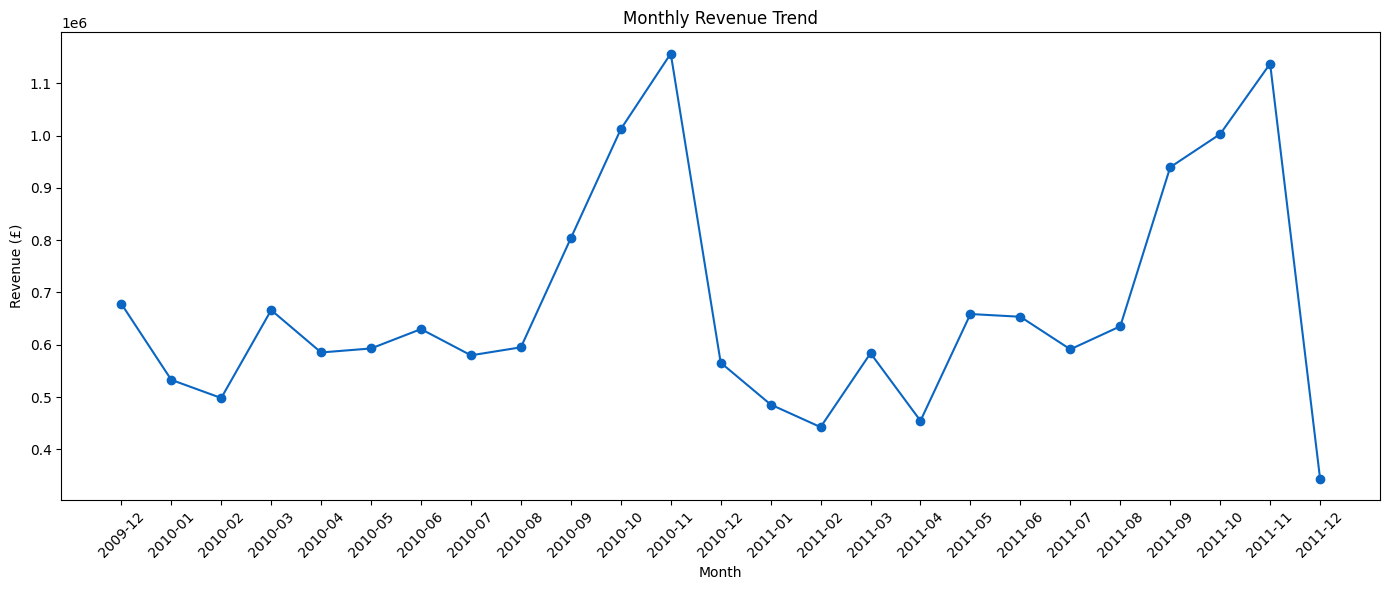

In [ ]:
# Monthly Sales Trend Analysis
import matplotlib.pyplot as plt

df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

monthly_sales = df.groupby('YearMonth')['Revenue'].sum().reset_index()
monthly_sales['YearMonth'] = monthly_sales['YearMonth'].astype(str)

print(monthly_sales)

# Visualization
plt.figure(figsize=(14,6))
plt.plot(monthly_sales['YearMonth'], monthly_sales['Revenue'], marker='o', color='#0A66C2')
plt.xticks(rotation=45)
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.show()

                           Description    Revenue
0             REGENCY CAKESTAND 3 TIER  277579.75
1   WHITE HANGING HEART T-LIGHT HOLDER  247027.36
2              JUMBO BAG RED RETROSPOT  134307.44
3        ASSORTED COLOUR BIRD ORNAMENT  124314.68
4                        PARTY BUNTING  103283.38
5       PAPER CHAIN KIT 50'S CHRISTMAS   76598.18
6                        CHILLI LIGHTS   69084.30
7                 JUMBO BAG STRAWBERRY   64127.77
8             BLACK RECORD COVER FRAME   63092.12
9  ROTATING SILVER ANGELS T-LIGHT HLDR   55877.62


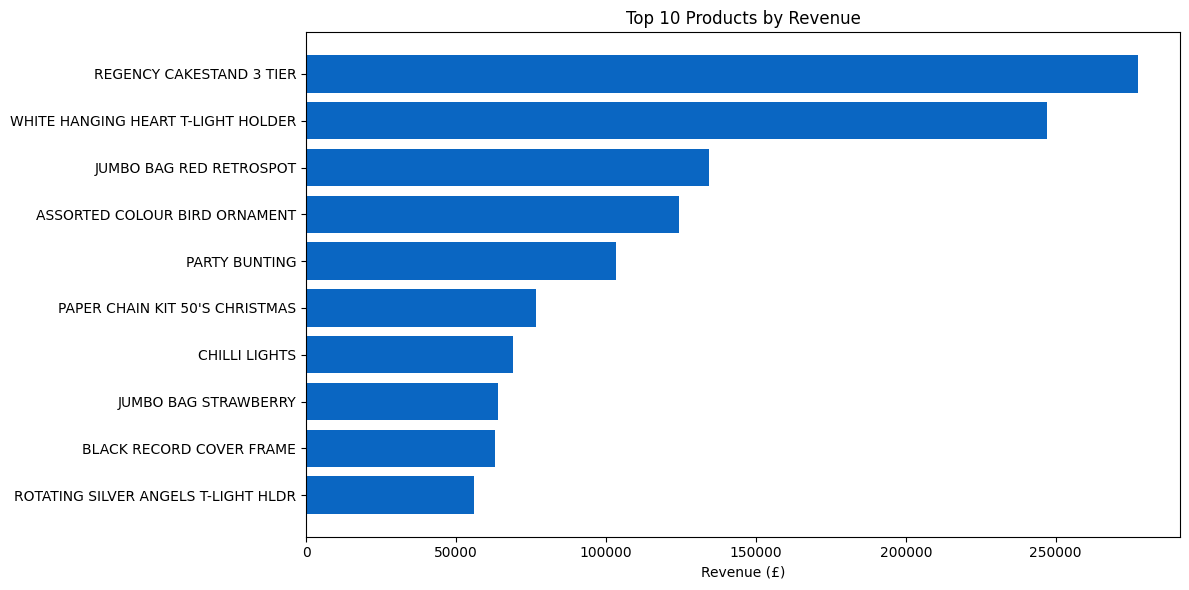

In [ ]:
# Top 10 Products by Revenue
top_products = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10).reset_index()
print(top_products)

plt.figure(figsize=(12,6))
plt.barh(top_products['Description'], top_products['Revenue'], color='#0A66C2')
plt.xlabel('Revenue (£)')
plt.title('Top 10 Products by Revenue')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

          Country       Revenue
0  United Kingdom  1.404739e+07
1            EIRE  5.956161e+05
2     Netherlands  5.497734e+05
3         Germany  3.832890e+05
4          France  3.097992e+05
5       Australia  1.678000e+05
6           Spain  9.776675e+04
7     Switzerland  9.340094e+04
8          Sweden  8.604514e+04
9         Denmark  6.742269e+04


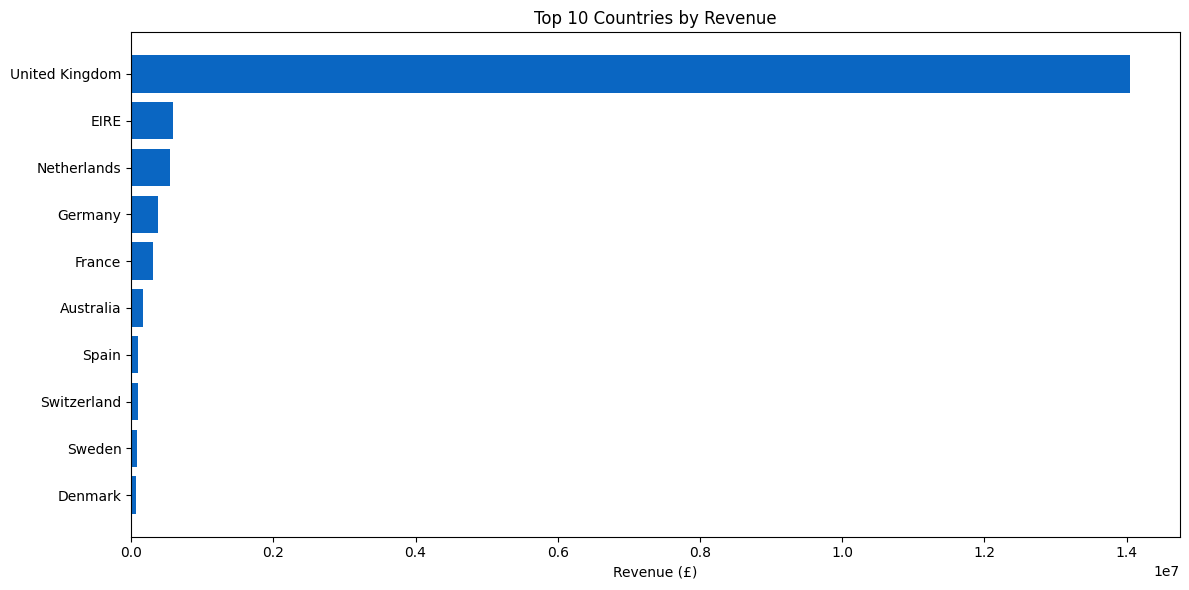

In [ ]:
# Top 10 Countries by Revenue
top_countries = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10).reset_index()
print(top_countries)

plt.figure(figsize=(12,6))
plt.barh(top_countries['Country'], top_countries['Revenue'], color='#0A66C2')
plt.xlabel('Revenue (£)')
plt.title('Top 10 Countries by Revenue')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
print(df['Country'].value_counts().head(10))

Country
United Kingdom    699725
Germany            15788
EIRE               15530
France             13036
Netherlands         4981
Spain               3560
Switzerland         2951
Belgium             2911
Portugal            2295
Australia           1783
Name: count, dtype: int64


   Customer ID    Revenue
0        18102  580987.04
1        14646  526751.52
2        14156  304719.88
3        14911  279492.79
4        17450  244784.25
5        13694  195640.69
6        17511  172132.87
7        16684  147142.77
8        12415  144033.37
9        15061  126387.57


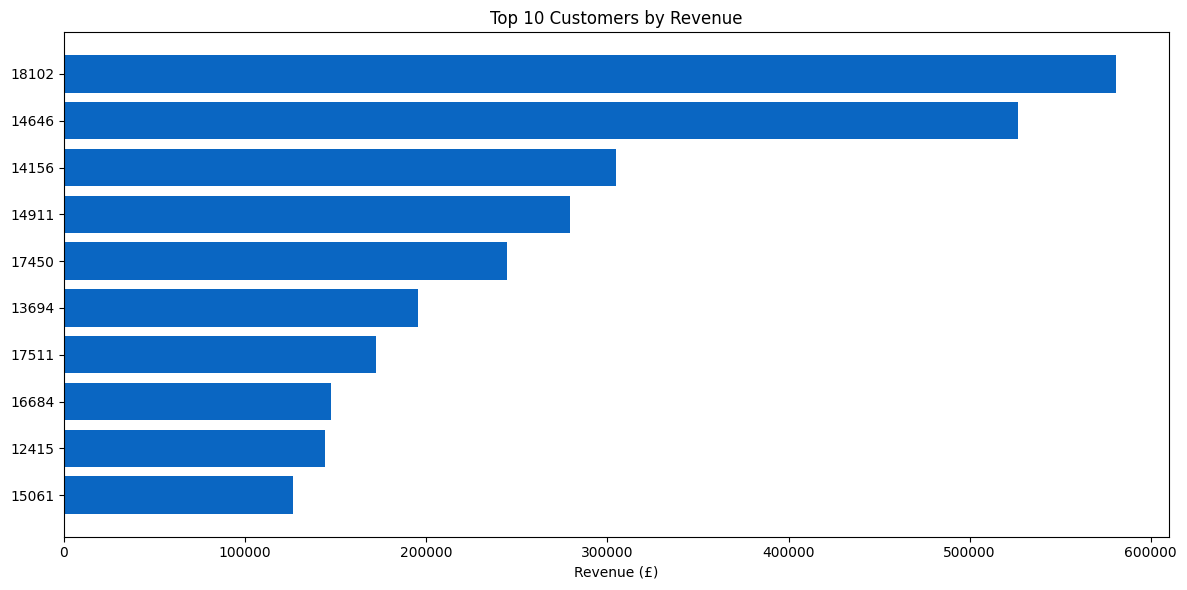

In [ ]:
# Top 10 Customers by Revenue
top_customers = df.groupby('Customer ID')['Revenue'].sum().sort_values(ascending=False).head(10).reset_index()
print(top_customers)

plt.figure(figsize=(12,6))
plt.barh(top_customers['Customer ID'].astype(str), top_customers['Revenue'], color='#0A66C2')
plt.xlabel('Revenue (£)')
plt.title('Top 10 Customers by Revenue')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# Return/Cancellation Analysis
df_raw = pd.concat([df_2009, df_2010], ignore_index=True)
returns = df_raw[df_raw['Invoice'].astype(str).str.startswith('C')]

print("Total cancelled/return orders:", len(returns))
print("Total orders (raw):", len(df_raw))
print("Return Rate:", round(len(returns)/len(df_raw)*100, 2), "%")

# Top 10 returned products
top_returns = returns.groupby('Description')['Quantity'].sum().sort_values().head(10).reset_index()
print(top_returns)

Total cancelled/return orders: 19494
Total orders (raw): 1067371
Return Rate: 1.83 %
                           Description  Quantity
0          PAPER CRAFT , LITTLE BIRDIE    -80995
1       MEDIUM CERAMIC TOP STORAGE JAR    -74494
2  ROTATING SILVER ANGELS T-LIGHT HLDR    -18750
3         SET/6 FRUIT SALAD PAPER CUPS     -7140
4      SET/6 FRUIT SALAD  PAPER PLATES     -7008
5                               Manual     -5450
6              POP ART PEN CASE & PENS     -5184
7   BLACK SILVER FLOWER T-LIGHT HOLDER     -5040
8        MULTICOLOUR SPRING FLOWER MUG     -4996
9              TEATIME PEN CASE & PENS     -4632


In [ ]:
# Return Analysis (excluding bulk outlier cancellations)
returns_clean = returns[returns['Quantity'] > -20000]
top_returns_clean = returns_clean.groupby('Description')['Quantity'].sum().sort_values().head(10).reset_index()
print(top_returns_clean)

                           Description  Quantity
0  ROTATING SILVER ANGELS T-LIGHT HLDR    -18750
1         SET/6 FRUIT SALAD PAPER CUPS     -7140
2      SET/6 FRUIT SALAD  PAPER PLATES     -7008
3                               Manual     -5450
4              POP ART PEN CASE & PENS     -5184
5   BLACK SILVER FLOWER T-LIGHT HOLDER     -5040
6        MULTICOLOUR SPRING FLOWER MUG     -4996
7              TEATIME PEN CASE & PENS     -4632
8         WHITE BIRD GARDEN DESIGN MUG     -4320
9       S/4 BLUE ROUND DECOUPAGE BOXES     -3940


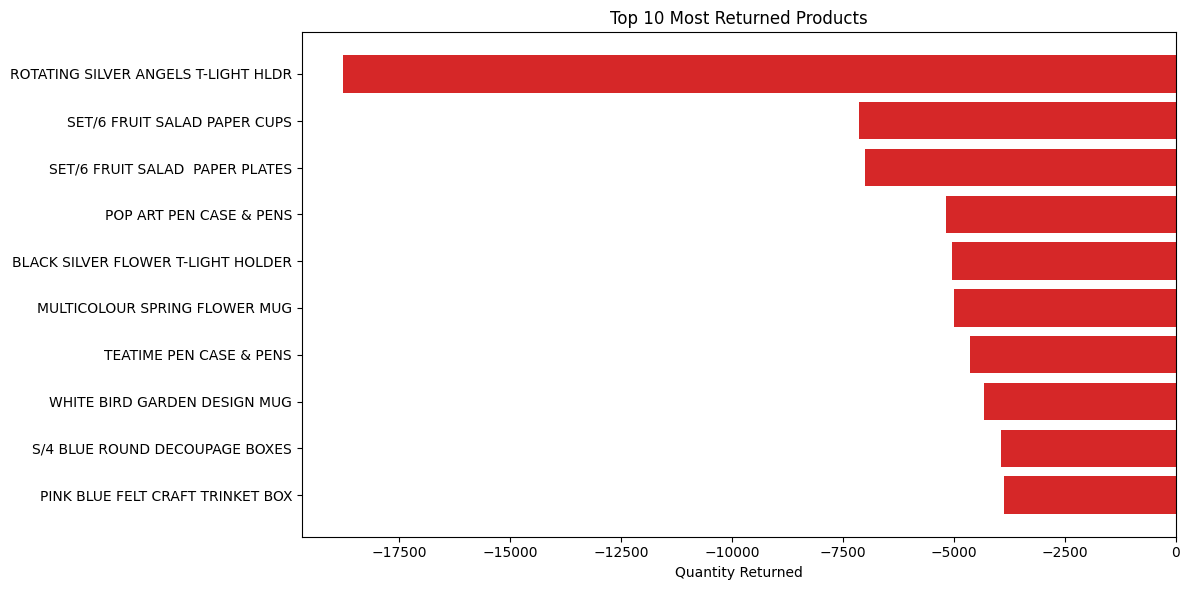

In [ ]:
# Top Returned Products (excluding bulk outliers and non-product entries)
top_returns_final = returns_clean[returns_clean['Description'] != 'Manual']
top_returns_final = top_returns_final.groupby('Description')['Quantity'].sum().sort_values().head(10).reset_index()

plt.figure(figsize=(12,6))
plt.barh(top_returns_final['Description'], top_returns_final['Quantity'], color='#D62728')
plt.xlabel('Quantity Returned')
plt.title('Top 10 Most Returned Products')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# RFM Customer Segmentation
import datetime as dt

reference_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'Invoice': 'nunique',
    'Revenue': 'sum'
}).reset_index()

rfm.columns = ['Customer ID', 'Recency', 'Frequency', 'Monetary']

print(rfm.head())

   Customer ID  Recency  Frequency  Monetary
0        12346      529         11    372.86
1        12347        2          8   4921.53
2        12348       75          5   1658.40
3        12349       19          3   3678.69
4        12350      310          1    294.40


In [ ]:
# RFM Scoring - Divide customers into segments
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

rfm['RFM_Score'] = rfm['R_Score'].astype(int) + rfm['F_Score'].astype(int) + rfm['M_Score'].astype(int)

def segment(score):
    if score >= 9:
        return 'High Value'
    elif score >= 6:
        return 'Medium Value'
    else:
        return 'Low Value'

rfm['Segment'] = rfm['RFM_Score'].apply(segment)

print(rfm['Segment'].value_counts())

Segment
High Value      2285
Medium Value    1832
Low Value       1730
Name: count, dtype: int64


In [ ]:
# Repeat vs One-Time Customer Analysis
customer_orders = df.groupby('Customer ID')['Invoice'].nunique().reset_index()
customer_orders.columns = ['Customer ID', 'Order Count']

customer_orders.loc[customer_orders['Order Count'] == 1, 'Customer Type'] = 'One-Time'
customer_orders.loc[customer_orders['Order Count'] > 1, 'Customer Type'] = 'Repeat'

print(customer_orders['Customer Type'].value_counts())
print(customer_orders['Customer Type'].value_counts(normalize=True) * 100)

Customer Type
Repeat      4229
One-Time    1618
Name: count, dtype: int64
Customer Type
Repeat      72.327689
One-Time    27.672311
Name: proportion, dtype: float64


In [ ]:
# Find all StockCodes that don't start with a number (likely non-product entries)
non_product_check = df[~df['StockCode'].astype(str).str[0].str.isdigit()]
print(non_product_check['StockCode'].value_counts())

StockCode
C2              248
BANK CHARGES     31
PADS             17
TEST001           9
ADJUST2           3
SP1002            2
TEST002           1
Name: count, dtype: int64


In [ ]:
print(df[df['StockCode'] == 'SP1002'][['StockCode', 'Description']].drop_duplicates())

       StockCode             Description
377066    SP1002  KID'S CHALKBOARD/EASEL


In [ ]:
non_product_final = ['C2', 'BANK CHARGES', 'TEST001', 'TEST002', 'ADJUST2']
df = df[~df['StockCode'].isin(non_product_final)]
df['Revenue'] = df['Revenue'].round(2)

print("Final shape:", df.shape)

Final shape: (776076, 10)


In [ ]:
df.to_csv('online_retail_cleaned.csv', index=False)
rfm.to_csv('rfm_segments.csv', index=False)

In [ ]:
# Export returns data for Power BI
returns_final = returns_clean[returns_clean['Description'] != 'Manual']
returns_final.to_csv('returns_data.csv', index=False)